In [ ]:
import numpy as np, matplotlib.pyplot as plt, pandas as pd, seaborn as sns
import os, glob

from data.movie import Frames, Audio, People # Measures
from data.spikes import Rates # LFP, BOLD
from data.behavior import Gaze, Suspense # Suspense, Valence, Arousal

from tqdm import tqdm

In [14]:
people = People().rescale(1)
people

array([0., 0., 0., 0., 0., 0., 0., 2., 2., 2., 2., 2., 2., 2., 2., 1., 1.,
       1., 1., 1., 1., 1., 2., 2., 2., 2., 2., 2., 4., 4., 4., 4., 4., 4.,
       4., 4., 4., 4., 2., 2., 2., 0., 0., 0., 0., 0., 0., 1., 1., 2., 3.,
       3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 2., 2., 2., 2., 2., 0., 0., 0., 0.,
       0., 0., 1., 1., 1., 1., 0., 0., 1., 1., 0., 0., 0., 0., 0., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 1., 1., 1., 0.,
       0., 1., 0., 0., 0., 0., 0., 0., 1., 1., 1., 0., 0., 0., 0., 0., 0.,
       0., 0., 1., 1., 1., 0., 0., 0., 1., 1., 0., 0., 0., 0., 0., 1., 1.,
       1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0.,
       0., 1., 0., 0., 1., 1., 2., 2., 2., 2., 1., 1., 1., 0., 0., 1., 1.,
       1., 1., 1., 2., 2., 2., 2., 2., 2., 2., 2., 2., 1., 1., 0., 0., 0.,
       0., 0., 0., 2., 2., 2., 2., 2., 0., 0., 0., 0., 0., 0., 2., 2., 2.,
       1., 1., 1., 1., 1.

### helpers

In [2]:
rescale_t = 1

min_max = lambda x: (x - x.min()) / (x.max() - x.min())

def remove_nans_inf_outliers(T_by_N):

    clean_T_by_N = T_by_N.copy()
    clean_T_by_N = clean_T_by_N[:, np.isfinite(T_by_N).all(axis=0)] # remove nans/infs
    clean_T_by_N = clean_T_by_N[:, clean_T_by_N.mean(axis=0) > 0.1] # remove low FR neurs
    
    print(f'dropping {T_by_N.shape[1] - clean_T_by_N.shape[1]} neurs.\nRetaining {clean_T_by_N.shape[1]} neurs.')

    return clean_T_by_N

def get_region_mtx(df, region):

    region_cols = [col for col in df.columns if region in col]
    region_mtx = df[region_cols].copy().values
    clean_mtx = remove_nans_inf_outliers(region_mtx)

    return clean_mtx, clean_mtx.T # T_by_N, N_by_T



# loading/formatting data

### X: neur_N_by_T

In [3]:
df_FRs = Rates().rescale(rescale_t)

regions = ['ACC', 'amygdala', 'hippocampus', 'vmPFC', 'preSMA']
amyg_T_by_N, amyg_N_by_T = get_region_mtx(df_FRs, 'amyg')
ACC_T_by_N, ACC_N_by_T = get_region_mtx(df_FRs, 'ACC')
hippo_T_by_N, hippo_N_by_T = get_region_mtx(df_FRs, 'hippo')
vmPFC_T_by_N, vmPFC_N_by_T = get_region_mtx(df_FRs, 'vmPFC')
preSMA_T_by_N, preSMA_N_by_T = get_region_mtx(df_FRs, 'preSMA')

df_FRs

dropping 239 neurs.
Retaining 243 neurs.
dropping 114 neurs.
Retaining 122 neurs.
dropping 150 neurs.
Retaining 114 neurs.
dropping 76 neurs.
Retaining 99 neurs.
dropping 153 neurs.
Retaining 147 neurs.


/home/nuttidalab/Documents/movie_analysis/data/spikes/rate.py:51: RuntimeWarning: divide by zero encountered in divide
  enc_rate_normed = (enc_rates - base_mean) / base_sd
/home/nuttidalab/Documents/movie_analysis/data/spikes/rate.py:51: RuntimeWarning: invalid value encountered in divide
  enc_rate_normed = (enc_rates - base_mean) / base_sd


,Left_ACC_P58CS_R1_1_1_994_6,Right_ACC_P58CS_R1_35_2_2425_5,Right_ACC_P58CS_R1_35_1_2195_5,Right_ACC_P58CS_R1_34_4_3301_5,Right_ACC_P58CS_R1_34_3_3299_5,Right_ACC_P58CS_R1_34_2_3239_5,Right_ACC_P58CS_R1_34_1_3232_5,Right_ACC_P58CS_R1_36_1_712_5,Right_ACC_P58CS_R1_36_2_962_5,Right_ACC_P58CS_R1_38_1_1473_5,...,Right_amygdala_P62CS_R1_28_1_6059_3,Right_amygdala_P62CS_R1_27_3_8498_3,Right_preSMA_P62CS_R1_22_3_2598_7,Right_preSMA_P62CS_R1_22_2_2532_7,Right_preSMA_P62CS_R1_22_1_2407_7,Right_preSMA_P62CS_R1_18_3_3847_7,Right_preSMA_P62CS_R1_18_2_3846_7,Right_preSMA_P62CS_R1_18_1_3830_7,Right_vmPFC_P62CS_R1_7_1_791_9,Right_vmPFC_P62CS_R1_5_1_1374_9
0.0,-0.338208,-0.374166,-0.107521,-0.923221,0.257964,-0.088289,-0.390434,2.244494,0.302122,0.393852,...,-0.171499,NaN,-0.188950,-0.485326,-0.171499,0.024249,1.280264,-0.589448,-0.457766,-0.062201
1.0,-0.338208,-0.374166,-0.107521,-1.000089,-0.574717,0.340222,-0.390434,2.887818,1.296439,1.549817,...,-0.171499,NaN,-0.150624,-0.485259,-0.171499,0.050365,0.209403,-0.589448,-0.005204,-0.294342
2.0,-0.338208,-0.374166,-0.107521,-0.134325,-0.131042,0.593294,-0.390312,6.613831,1.113987,0.294318,...,-0.171499,NaN,0.703743,-0.333462,-0.171499,-0.211629,0.858131,-0.589448,-0.225080,-0.296496
3.0,-0.338208,-0.374166,-0.107521,2.040038,0.232627,0.389511,0.292734,2.013020,1.050507,1.038302,...,-0.171499,NaN,-0.325370,-0.220164,-0.171499,0.095727,0.476378,-0.589448,0.028679,-0.220789
4.0,-0.338208,-0.374166,-0.107521,0.512235,-0.722726,-0.457154,0.516420,0.090433,0.260862,0.102534,...,-0.171499,NaN,-0.356894,-0.485191,-0.171499,-0.159577,0.302962,-0.589448,0.120814,0.327731
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
474.0,-0.338208,-0.374041,-0.107521,0.031678,-0.117056,0.119806,0.087395,-0.107521,-0.257123,-0.462101,...,-0.171499,NaN,0.281662,-0.369646,-0.171499,-0.133381,0.812446,0.008545,0.228790,0.044538
475.0,-0.338208,0.037009,0.076115,-0.292360,-0.133325,0.286691,-0.116771,-0.107521,0.219609,0.014690,...,-0.171499,NaN,0.371900,-0.133950,-0.171499,-0.256176,-0.409717,0.260416,0.229811,0.703491
476.0,-0.338208,1.043194,2.844863,-0.093900,-0.574784,0.245846,-0.386153,-0.107521,0.709171,-0.455701,...,-0.171499,NaN,-0.396999,-0.151995,-0.162363,0.368297,-0.000177,-0.264589,0.352840,0.230458
477.0,-0.338208,-0.015422,2.233755,0.705968,-0.117106,0.836228,0.455036,0.030206,0.268840,-0.489116,...,-0.171499,NaN,0.089519,0.135114,1.234392,-0.226664,-0.224824,0.067774,0.028679,0.538756


dropping 732 neurs.
Retaining 725 neurs.
(725, 479)


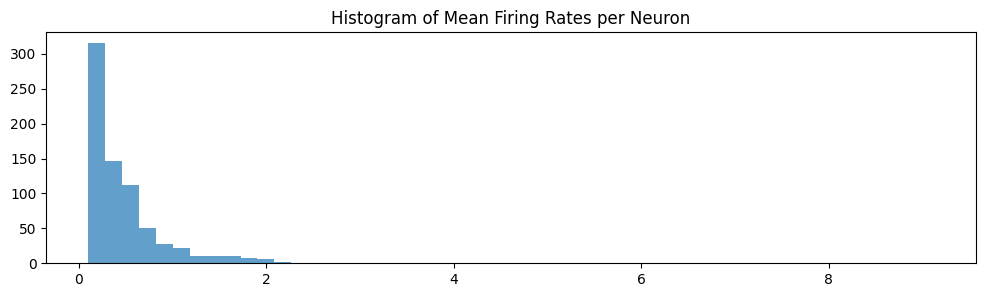

In [4]:
# store as arr
neur_T_by_N = remove_nans_inf_outliers(df_FRs.values)
neur_N_by_T = neur_T_by_N.T
print(neur_N_by_T.shape)

plt.figure(figsize=(12, 3))
plt.hist(neur_T_by_N.mean(axis=0), bins=50, alpha=0.7)
plt.title('Histogram of Mean Firing Rates per Neuron')
plt.show()


### Y1: aud_N_by_T

In [5]:
audio = Audio()
audio_metrics = [
    audio.vocals.arousal,
    audio.vocals.dominance,
    audio.vocals.valence,
    audio.vocals.sad,
    audio.vocals.happy,
    audio.vocals.neutral,
]

(6, 479)


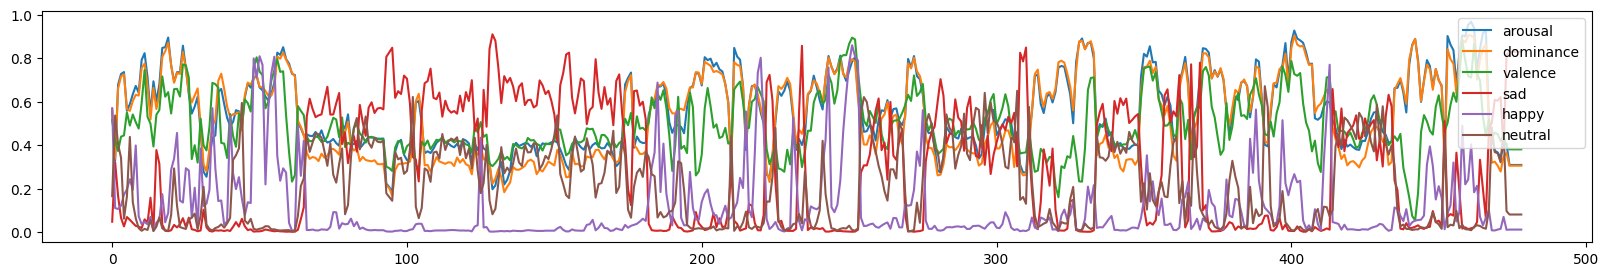

In [6]:
# apply rescaling and stack into a matrix
rescaled_metrics = [data.rescale(1) for data in audio_metrics]
aud_T_by_N = np.stack(rescaled_metrics, axis=1)
aud_N_by_T = aud_T_by_N.T
print(aud_N_by_T.shape)

# plot
df_audio = pd.DataFrame(aud_T_by_N, columns=['arousal', 'dominance', 'valence','sad', 'happy','neutral'])
plt.figure(figsize=(20, 3))
for col in df_audio.columns:
    plt.plot(df_audio[col], label=col)
plt.legend()
plt.show()

### Y2: susp_N_T

(1, 479)


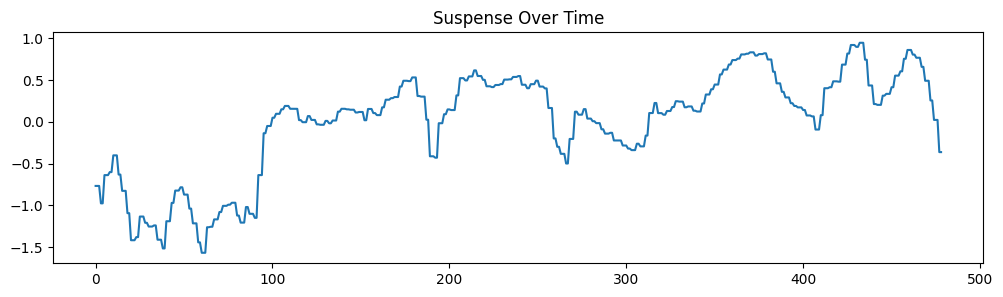

In [7]:
suspense = Suspense().rescale(rescale_t)
avg_suspense = suspense.mean(axis=1)
susp_N_by_T = avg_suspense[np.newaxis, :]
print(susp_N_by_T.shape)

plt.figure(figsize=(12, 3))
plt.title('Suspense Over Time')
plt.plot(avg_suspense)
plt.show()

# decoding persistence

In [8]:
from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.metrics import make_scorer
from sklearn.model_selection import KFold, cross_val_score, permutation_test_score

In [9]:
# pca on X & Y
pca = PCA(n_components=10)
neur_PC_by_T = pca.fit_transform(neur_T_by_N).T
print(neur_PC_by_T.shape)

pca = PCA(n_components=3)
aud_PC_by_T = pca.fit_transform(aud_T_by_N).T
print(aud_PC_by_T.shape)

# setup variables
delta_t = 5
X = neur_PC_by_T#.flatten() to (1, T)
Y = aud_PC_by_T#.flatten() to (1, T)

(10, 479)
(3, 479)


Weights vector shape: (50,)
Train‐set Pearson r = 0.625


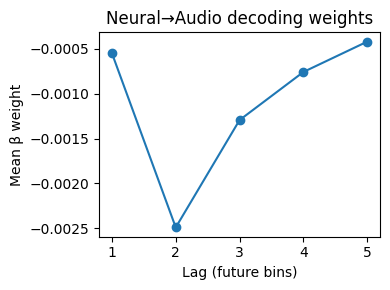

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge

# assume these are already defined:
#   neur_PC_by_T : np.ndarray, shape (n_neur, T)
#   aud_PC_by_T  : np.ndarray, shape (n_aud,  T)

delta_t = 5
n_neur, T = neur_PC_by_T.shape

# 1) Build X (future neural PCs) and Y (current audio‐PC1)
X = np.stack([
    neur_PC_by_T[:, t+1:t+1+delta_t].flatten(order='F')
    for t in range(T - delta_t)
])               # shape = (T-delta_t, n_neur*delta_t)

Y = aud_PC_by_T[0, :T - delta_t]  # predicting audio‐PC1 at time t

# 2) Fit a ridge regression
model = Ridge(alpha=1.0)
model.fit(X, Y)

# 3) Extract weights and compute training‐set correlation
w    = model.coef_                 # length = n_neur * delta_t
Yhat = model.predict(X)
r    = np.corrcoef(Y, Yhat)[0,1]

print(f"Weights vector shape: {w.shape}")
print(f"Train‐set Pearson r = {r:.3f}")

# 4) Plot the average weight at each future lag (averaging over neurons)
w_by_lag = w.reshape(n_neur, delta_t, order='F').mean(axis=0)
plt.figure(figsize=(4,3))
plt.plot(np.arange(1, delta_t+1), w_by_lag, 'o-')
plt.xlabel('Lag (future bins)')
plt.ylabel('Mean β weight')
plt.title('Neural→Audio decoding weights')
plt.tight_layout()
plt.show()


5‐fold CV r’s: [0.543 0.363 0.536 0.632 0.473] → mean: 0.509
Perm. p‐value: 0.005


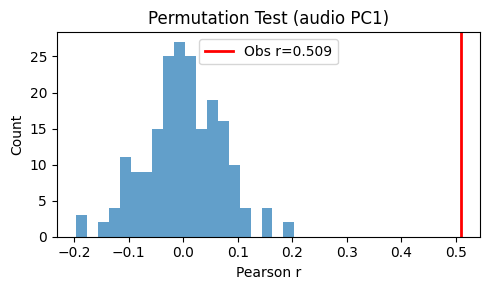

In [11]:
# ─── Build design matrix of FUTURE neural PCs → current audio-PC1 ────────────
T = neur_PC_by_T.shape[1]
n_neur = neur_PC_by_T.shape[0]

# X_future shape: (T - delta_t, n_neur * delta_t)
X_future = np.zeros((T - delta_t, n_neur * delta_t))
# Y_current shape: (T - delta_t,)
Y_current = np.zeros(T - delta_t)

for t in range(T - delta_t):
    # use neural PCs at t+1 ... t+delta_t to predict audio at t
    window = neur_PC_by_T[:, t+1:t+1+delta_t]
    X_future[t] = window.reshape(-1, order='F')
    # predict PC1 of audio
    Y_current[t] = aud_PC_by_T[0, t]

# ─── Set up model, CV, and scorer ─────────────────────────────────────────────
# Pearson-r scorer
corr_scorer = make_scorer(lambda y, yhat: np.corrcoef(y, yhat)[0,1])

# RidgeCV to pick alpha
model = RidgeCV(alphas=[0.1, 1.0, 10.0])
cv = KFold(n_splits=5, shuffle=True, random_state=0)

# ─── 5‐fold CV performance ────────────────────────────────────────────────────
cv_rs = cross_val_score(model, X_future, Y_current, cv=cv, scoring=corr_scorer)
print("5‐fold CV r’s:", np.round(cv_rs,3), "→ mean:", np.round(cv_rs.mean(),3))

# ─── Permutation test ─────────────────────────────────────────────────────────
score, perm_rs, pval = permutation_test_score(
    model, X_future, Y_current,
    scoring=corr_scorer,
    cv=cv,
    n_permutations=200,
    random_state=1
)
print("Perm. p‐value:", np.round(pval,3))

# ─── Plot null distribution vs. observed ──────────────────────────────────────
plt.figure(figsize=(5,3))
plt.hist(perm_rs, bins=20, alpha=0.7)
plt.axvline(score, color='r', lw=2, label=f'Obs r={score:.3f}')
plt.title('Permutation Test (audio PC1)')
plt.xlabel('Pearson r'); plt.ylabel('Count')
plt.legend(); plt.tight_layout(); plt.show()

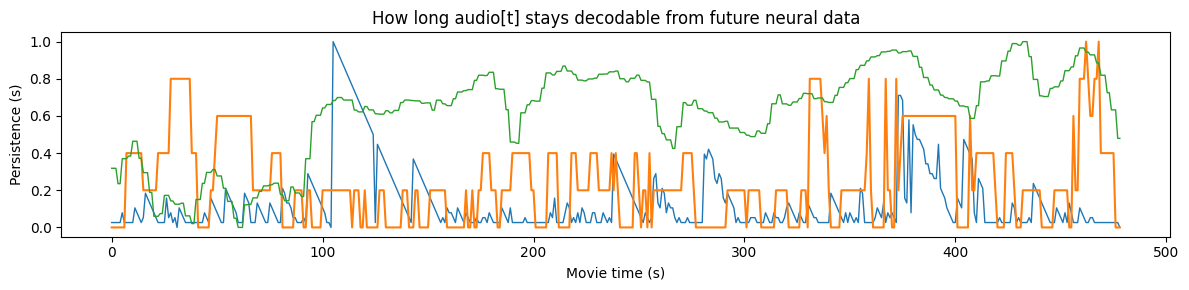

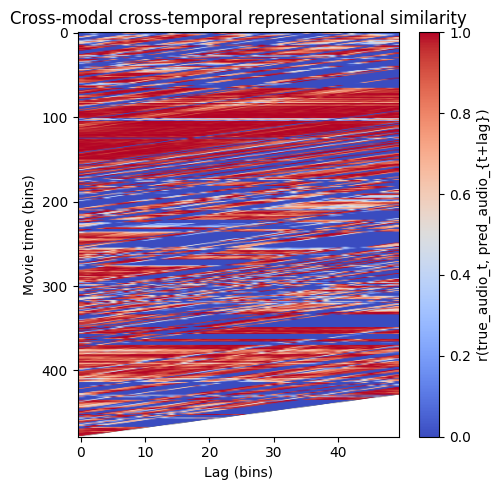

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import RidgeCV

# 1) Fit decoder on current time
# neur_PC_by_T: (N_neur, T); aud_PC_by_T: (D_aud, T)
X = neur_PC_by_T.T            # shape (T, N_neur)
Y = aud_PC_by_T.T             # shape (T, D_aud)
decoder = RidgeCV(alphas=[0.1,1,10]).fit(X, Y)

# 2) Predict audio PCs from future neural PCs
T = neur_PC_by_T.shape[1]
max_lag = 50   # how far into the future to test (bins)
corrs = np.zeros((T, max_lag))

for t in range(T):
    true_vec = aud_PC_by_T[:, t]  # (D_aud,)
    for lag in range(1, max_lag+1):
        if t+lag < T:
            pred_vec = decoder.predict(neur_PC_by_T[:, t+lag].reshape(1,-1))[0]
            # correlation across the D_aud dimensions
            corrs[t, lag-1] = np.corrcoef(true_vec, pred_vec)[0,1]
        else:
            corrs[t, lag-1] = np.nan

# 3) Compute persistence: how many bins until corr drops below threshold
threshold = 0.5
persistence = np.zeros(T)
for t in range(T):
    valid = ~np.isnan(corrs[t])
    above = corrs[t, valid] >= threshold
    # find first False index (or use all if stays above)
    if above.any():
        persistence[t] = np.argmax(~above) + 1
    else:
        persistence[t] = 0

# 4) Plot persistence over movie time
bin_dur = 1.0   # seconds per bin
plt.figure(figsize=(12,3))
plt.plot(np.arange(T)*bin_dur, min_max(persistence*bin_dur), lw=1)
plt.plot(min_max(people))
plt.plot(min_max(avg_suspense), lw=1)
plt.xlabel('Movie time (s)')
plt.ylabel('Persistence (s)')
plt.title('How long audio[t] stays decodable from future neural data')
plt.tight_layout()
plt.show()

# 5) (Optional) visualize the full corr matrix
plt.figure(figsize=(5,5))
plt.imshow(corrs, aspect='auto', vmin=0, vmax=1, cmap='coolwarm')
plt.colorbar(label='r(true_audio_t, pred_audio_{t+lag})')
plt.xlabel('Lag (bins)')
plt.ylabel('Movie time (bins)')
plt.title('Cross-modal cross-temporal representational similarity')
plt.tight_layout()
plt.show()
